In [3]:
import numpy as np
from matplotlib import pyplot as plt
import pickle
import os, sys
import torch
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from collections import defaultdict
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap, BoundaryNorm
import torch
import numpy as np
# Root project
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))

if project_root not in sys.path:
    sys.path.append(project_root)

print("Project root added to sys.path:", project_root)

from envs import *
from basal_ganglia import *
from stn_gpe import *

# filter warnings
import warnings
warnings.filterwarnings("ignore")



plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],  # Times for publication
    "font.size": 9,                    # Base font size
    "axes.labelsize": 9,              # Axis label font size
    "axes.labelweight": "bold",
    "font.weight": "bold",   
    "axes.titlesize":8,              # Axis title (not fig title)
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize":8,              # Legend font size

    "figure.dpi": 300,                 # Display resolution
    "savefig.dpi": 300,                # Save resolution
    "figure.constrained_layout.use": True,  # Better spacing than tight_layout

    "axes.linewidth": 0.8,             # Thin but clear axes lines
    "lines.linewidth": 1.2,
    "lines.markersize": 5,

    "axes.spines.top": False,
    "axes.spines.right": False,

    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,

    "legend.frameon": False,
    "legend.handlelength": 2.0,        # Slightly longer legend lines
    "legend.handletextpad": 0.5,

    "pdf.fonttype": 42,                # Embed editable fonts in PDF
    "ps.fonttype": 42
})

import pickle
import os
import re
import glob
import pandas as pd

Project root added to sys.path: /Users/charithapalika/Desktop/Lab projects/Decision Making/light_house_DBS_decision_making


/Users/charithapalika/Desktop/Lab projects/Decision Making/light_house_DBS_decision_making/basal_ganglia/train.py:12: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


In [4]:



def compute_exploration_metrics(
    actions,
    n_arms=None,
    window_size=10,
    alpha=0.5
):
    """
    Compute rolling exploration metrics for multiple patients.

    Parameters
    ----------
    actions : torch.Tensor or np.ndarray
        Shape:
            (n_patients, n_trials)

        Contains arm selections.

    n_arms : int
        Total number of arms.
        If None -> inferred automatically.

    window_size : int
        Rolling window size.

    alpha : float
        Weight for combined exploration score.

        combined_score =
            alpha * entropy +
            (1-alpha) * switching_rate

    Returns
    -------
    results : dict

        {
            'entropy': tensor (n_patients, T-window+1),
            'switching': tensor (n_patients, T-window+1),
            'combined_score': tensor (n_patients, T-window+1),
            'mean_entropy': tensor (n_patients,),
            'mean_switching': tensor (n_patients,),
            'mean_combined': tensor (n_patients,)
        }
    """

    # convert to tensor
    if isinstance(actions, np.ndarray):
        actions = torch.tensor(actions)

    actions = actions.long()

    n_patients, n_trials = actions.shape

    if n_arms is None:
        n_arms = int(actions.max().item()) + 1

    out_len = n_trials - window_size + 1

    entropy_all = torch.zeros((n_patients, out_len))
    switching_all = torch.zeros((n_patients, out_len))

    # max entropy normalization
    max_entropy = np.log(n_arms)

    for p in range(n_patients):

        patient_actions = actions[p]

        for t in range(out_len):

            w = patient_actions[t:t + window_size]

            # -------------------------
            # entropy
            # -------------------------
            counts = torch.bincount(
                w,
                minlength=n_arms
            ).float()

            probs = counts / counts.sum()

            probs = probs[probs > 0]

            entropy = -(probs * torch.log(probs)).sum()

            # normalize entropy
            entropy = entropy / max_entropy

            entropy_all[p, t] = entropy

            # -------------------------
            # switching rate
            # -------------------------
            switches = (
                w[1:] != w[:-1]
            ).float().mean()

            switching_all[p, t] = switches

    # combined exploration score
    combined = (
        alpha * entropy_all +
        (1 - alpha) * switching_all
    )

    results = {
        "entropy": entropy_all,
        "switching": switching_all,
        "combined_score": combined,
        "mean_entropy": entropy_all.mean(dim=1),
        "mean_switching": switching_all.mean(dim=1),
        "mean_combined": combined.mean(dim=1)
    }

    return results

In [5]:
data_folder = os.path.join(
    project_root,
    "results",
    "decision_making_tasks",
    "data",
    "non_stationary_bandits"
)

lat_files = sorted(glob.glob(
    os.path.join(data_folder, "non_stationary_bandits_v1_data_lat_*.pkl")
))

print("Found lateral strength files:")
for f in lat_files:
    print(os.path.basename(f))


# ============================================================
# Extract lateral strength from filename
# Example:
# non_stationary_bandits_v1_data_lat_0_0275.pkl -> 0.0275
# ============================================================

def extract_lat_strength_from_filename(file_path):
    fname = os.path.basename(file_path)
    match = re.search(r"lat_(\d+)_(\d+)", fname)

    if match is None:
        raise ValueError(f"Could not extract lateral strength from filename: {fname}")

    return float(match.group(1) + "." + match.group(2))


def to_float(x):
    if torch.is_tensor(x):
        return float(x.detach().cpu().item())
    if isinstance(x, np.ndarray):
        return float(x.item())
    return float(x)


# ============================================================
# Load normal baseline
# ============================================================

data_normal_file_v1 = os.path.join(
    data_folder,
    "non_stationary_bandits_v1_normal.pkl"
)

with open(data_normal_file_v1, "rb") as f:
    data_normal_v1 = pickle.load(f)

exp_res_normal = compute_exploration_metrics(
    data_normal_v1["ARM_CHOSEN_MONITOR"],
    n_arms=3,
    window_size=15,
    alpha=0.7
)

normal_mean_combined = torch.mean(exp_res_normal["mean_combined"]).item()
normal_mean_entropy = torch.mean(exp_res_normal["mean_entropy"]).item()
normal_mean_switching = torch.mean(exp_res_normal["mean_switching"]).item()

print("\nNormal baseline:")
print("Mean combined :", normal_mean_combined)
print("Mean entropy  :", normal_mean_entropy)
print("Mean switching:", normal_mean_switching)


# ============================================================
# Helper to extract ARM_MONITOR for each DEL_LIM
# Expected structure:
# data_all_NSB["ARM_MONITOR"]["PD"]["DEL_LIM_ARR[0]"]
# ============================================================

def get_arm_monitor_for_del_lim(data, condition_key, del_idx, del_value=None):
    condition_data = data["ARM_MONITOR"][condition_key]

    possible_keys = [
        f"DEL_LIM_ARR[{del_idx}]",
        str(del_idx),
        del_idx
    ]

    if del_value is not None:
        possible_keys.extend([
            str(del_value),
            str(to_float(del_value)),
            to_float(del_value)
        ])

    for key in possible_keys:
        if key in condition_data:
            return condition_data[key]

    raise KeyError(
        f"Could not find DEL_LIM for condition={condition_key}, "
        f"del_idx={del_idx}, del_value={del_value}. "
        f"Available keys: {list(condition_data.keys())}"
    )


# ============================================================
# Correct condition keys and fixed colors
# ============================================================

condition_keys = ["PD", "STD_DBS", "SECTOR_DBS"]

condition_labels = {
    "PD": "PD",
    "STD_DBS": "STD DBS",
    "SECTOR_DBS": "SECTOR DBS"
}

condition_colors = {
    "PD": "red",
    "STD_DBS": "orange",
    "SECTOR_DBS": "green"
}


# ============================================================
# Compute exploration metrics across all lateral strength files
# ============================================================

results = []

for file_path in lat_files:

    lat_strength = extract_lat_strength_from_filename(file_path)

    with open(file_path, "rb") as f:
        data_all_NSB = pickle.load(f)

    print("\nProcessing:", os.path.basename(file_path))
    print("Lat strength:", lat_strength)
    print("Available ARM_MONITOR keys:", list(data_all_NSB["ARM_MONITOR"].keys()))

    del_lim_arr = data_all_NSB["DEL_LIM_ARR"]
    
    for condition_key in condition_keys:

        if condition_key not in data_all_NSB["ARM_MONITOR"]:
            print(f"Skipping {condition_key}, not found.")
            continue

        for del_idx, del_lim in enumerate(del_lim_arr):

            arm_monitor = get_arm_monitor_for_del_lim(
                data=data_all_NSB,
                condition_key=condition_key,
                del_idx=del_idx,
                del_value=del_lim
            )

            exp_res = compute_exploration_metrics(
                arm_monitor,
                n_arms=3,
                window_size=15,
                alpha=0.7
            )

            mean_combined = torch.mean(exp_res["mean_combined"]).item()
            mean_entropy = torch.mean(exp_res["mean_entropy"]).item()
            mean_switching = torch.mean(exp_res["mean_switching"]).item()

            results.append({
                "Condition": condition_key,
                "Condition_label": condition_labels[condition_key],
                "Lat_strength": lat_strength,
                "Del_lim": to_float(del_lim),
                "Mean_combined": mean_combined,
                "Mean_entropy": mean_entropy,
                "Mean_switching": mean_switching
            })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by=["Lat_strength", "Condition", "Del_lim"]
).reset_index(drop=True)

display(results_df)

Found lateral strength files:
non_stationary_bandits_v1_data_lat_0_0275.pkl
non_stationary_bandits_v1_data_lat_0_0325.pkl
non_stationary_bandits_v1_data_lat_0_0375.pkl
non_stationary_bandits_v1_data_lat_0_0425.pkl
non_stationary_bandits_v1_data_lat_0_0475.pkl

Normal baseline:
Mean combined : 0.08129611611366272
Mean entropy  : 0.09494012594223022
Mean switching: 0.04946012794971466

Processing: non_stationary_bandits_v1_data_lat_0_0275.pkl
Lat strength: 0.0275
Available ARM_MONITOR keys: ['PD', 'STD_DBS', 'SECTOR_DBS']

Processing: non_stationary_bandits_v1_data_lat_0_0325.pkl
Lat strength: 0.0325
Available ARM_MONITOR keys: ['PD', 'STD_DBS', 'SECTOR_DBS']

Processing: non_stationary_bandits_v1_data_lat_0_0375.pkl
Lat strength: 0.0375
Available ARM_MONITOR keys: ['PD', 'STD_DBS', 'SECTOR_DBS']

Processing: non_stationary_bandits_v1_data_lat_0_0425.pkl
Lat strength: 0.0425
Available ARM_MONITOR keys: ['PD', 'STD_DBS', 'SECTOR_DBS']

Processing: non_stationary_bandits_v1_data_lat_0_0475

,Condition,Condition_label,Lat_strength,Del_lim,Mean_combined,Mean_entropy,Mean_switching
0,PD,PD,0.0275,0.1,0.465127,0.524519,0.326545
1,PD,PD,0.0275,0.2,0.014174,0.017703,0.005939
2,PD,PD,0.0275,0.5,0.011588,0.015021,0.003580
3,PD,PD,0.0275,1.0,0.014174,0.017703,0.005939
4,SECTOR_DBS,SECTOR DBS,0.0275,0.1,0.543034,0.602544,0.404178
5,SECTOR_DBS,SECTOR DBS,0.0275,0.2,0.089314,0.104180,0.054626
6,SECTOR_DBS,SECTOR DBS,0.0275,0.5,0.091761,0.107327,0.055440
7,SECTOR_DBS,SECTOR DBS,0.0275,1.0,0.089314,0.104180,0.054626
8,STD_DBS,STD DBS,0.0275,0.1,0.448624,0.502556,0.322782
9,STD_DBS,STD DBS,0.0275,0.2,0.013959,0.017422,0.005880


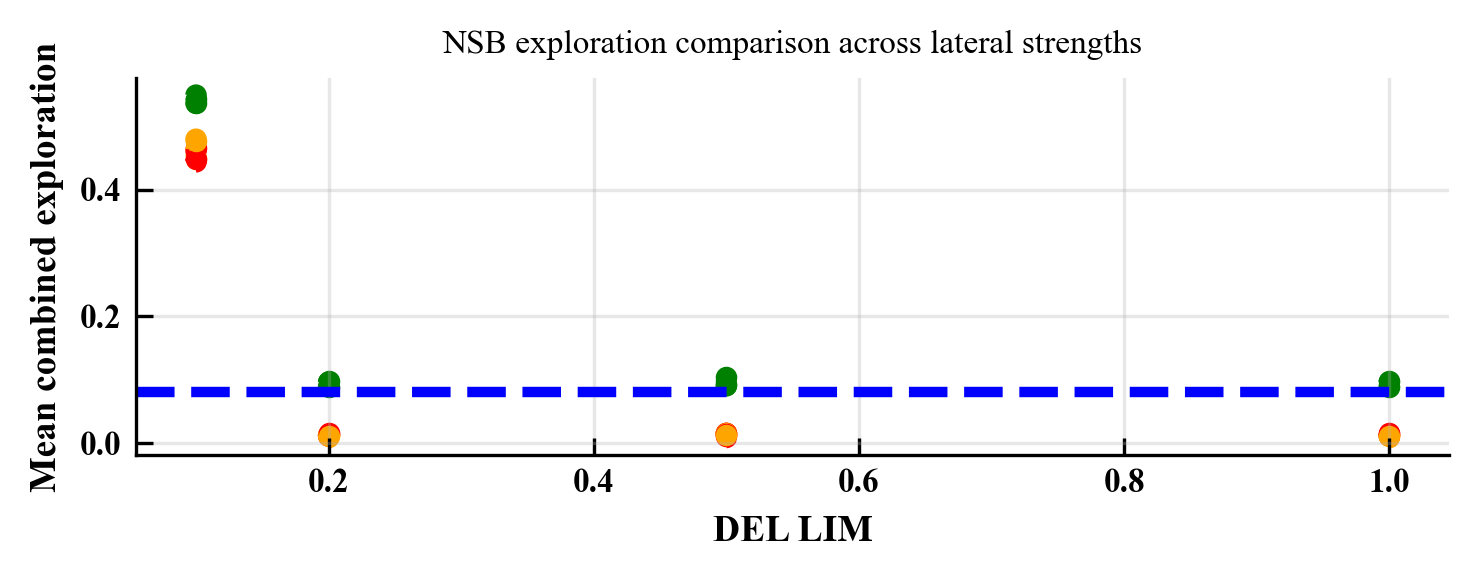

In [33]:
line_styles = ["-", "--", "-.", ":"]

plt.figure(figsize=(5,2))

lat_strengths = sorted(results_df["Lat_strength"].unique())

for lat_idx, lat_strength in enumerate(lat_strengths):

    temp_lat = results_df[results_df["Lat_strength"] == lat_strength]
    linestyle = line_styles[lat_idx % len(line_styles)]

    for condition_key in condition_keys:

        temp = temp_lat[temp_lat["Condition"] == condition_key]
        temp = temp.sort_values("Del_lim")

        if len(temp) == 0:
            continue

        plt.scatter(
            temp["Del_lim"],
            temp["Mean_combined"],
            marker="o",
            s = 10,
            linewidth=2,
            linestyle=linestyle,
            color=condition_colors[condition_key],
            label=f"{condition_labels[condition_key]} | Lat={lat_strength}"
        )

plt.axhline(
    normal_mean_combined,
    linestyle="--",
    linewidth=2.5,
    color="blue",
    label="Normal"
)

plt.xlabel("DEL LIM")
plt.ylabel("Mean combined exploration")
plt.title("NSB exploration comparison across lateral strengths")
# plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

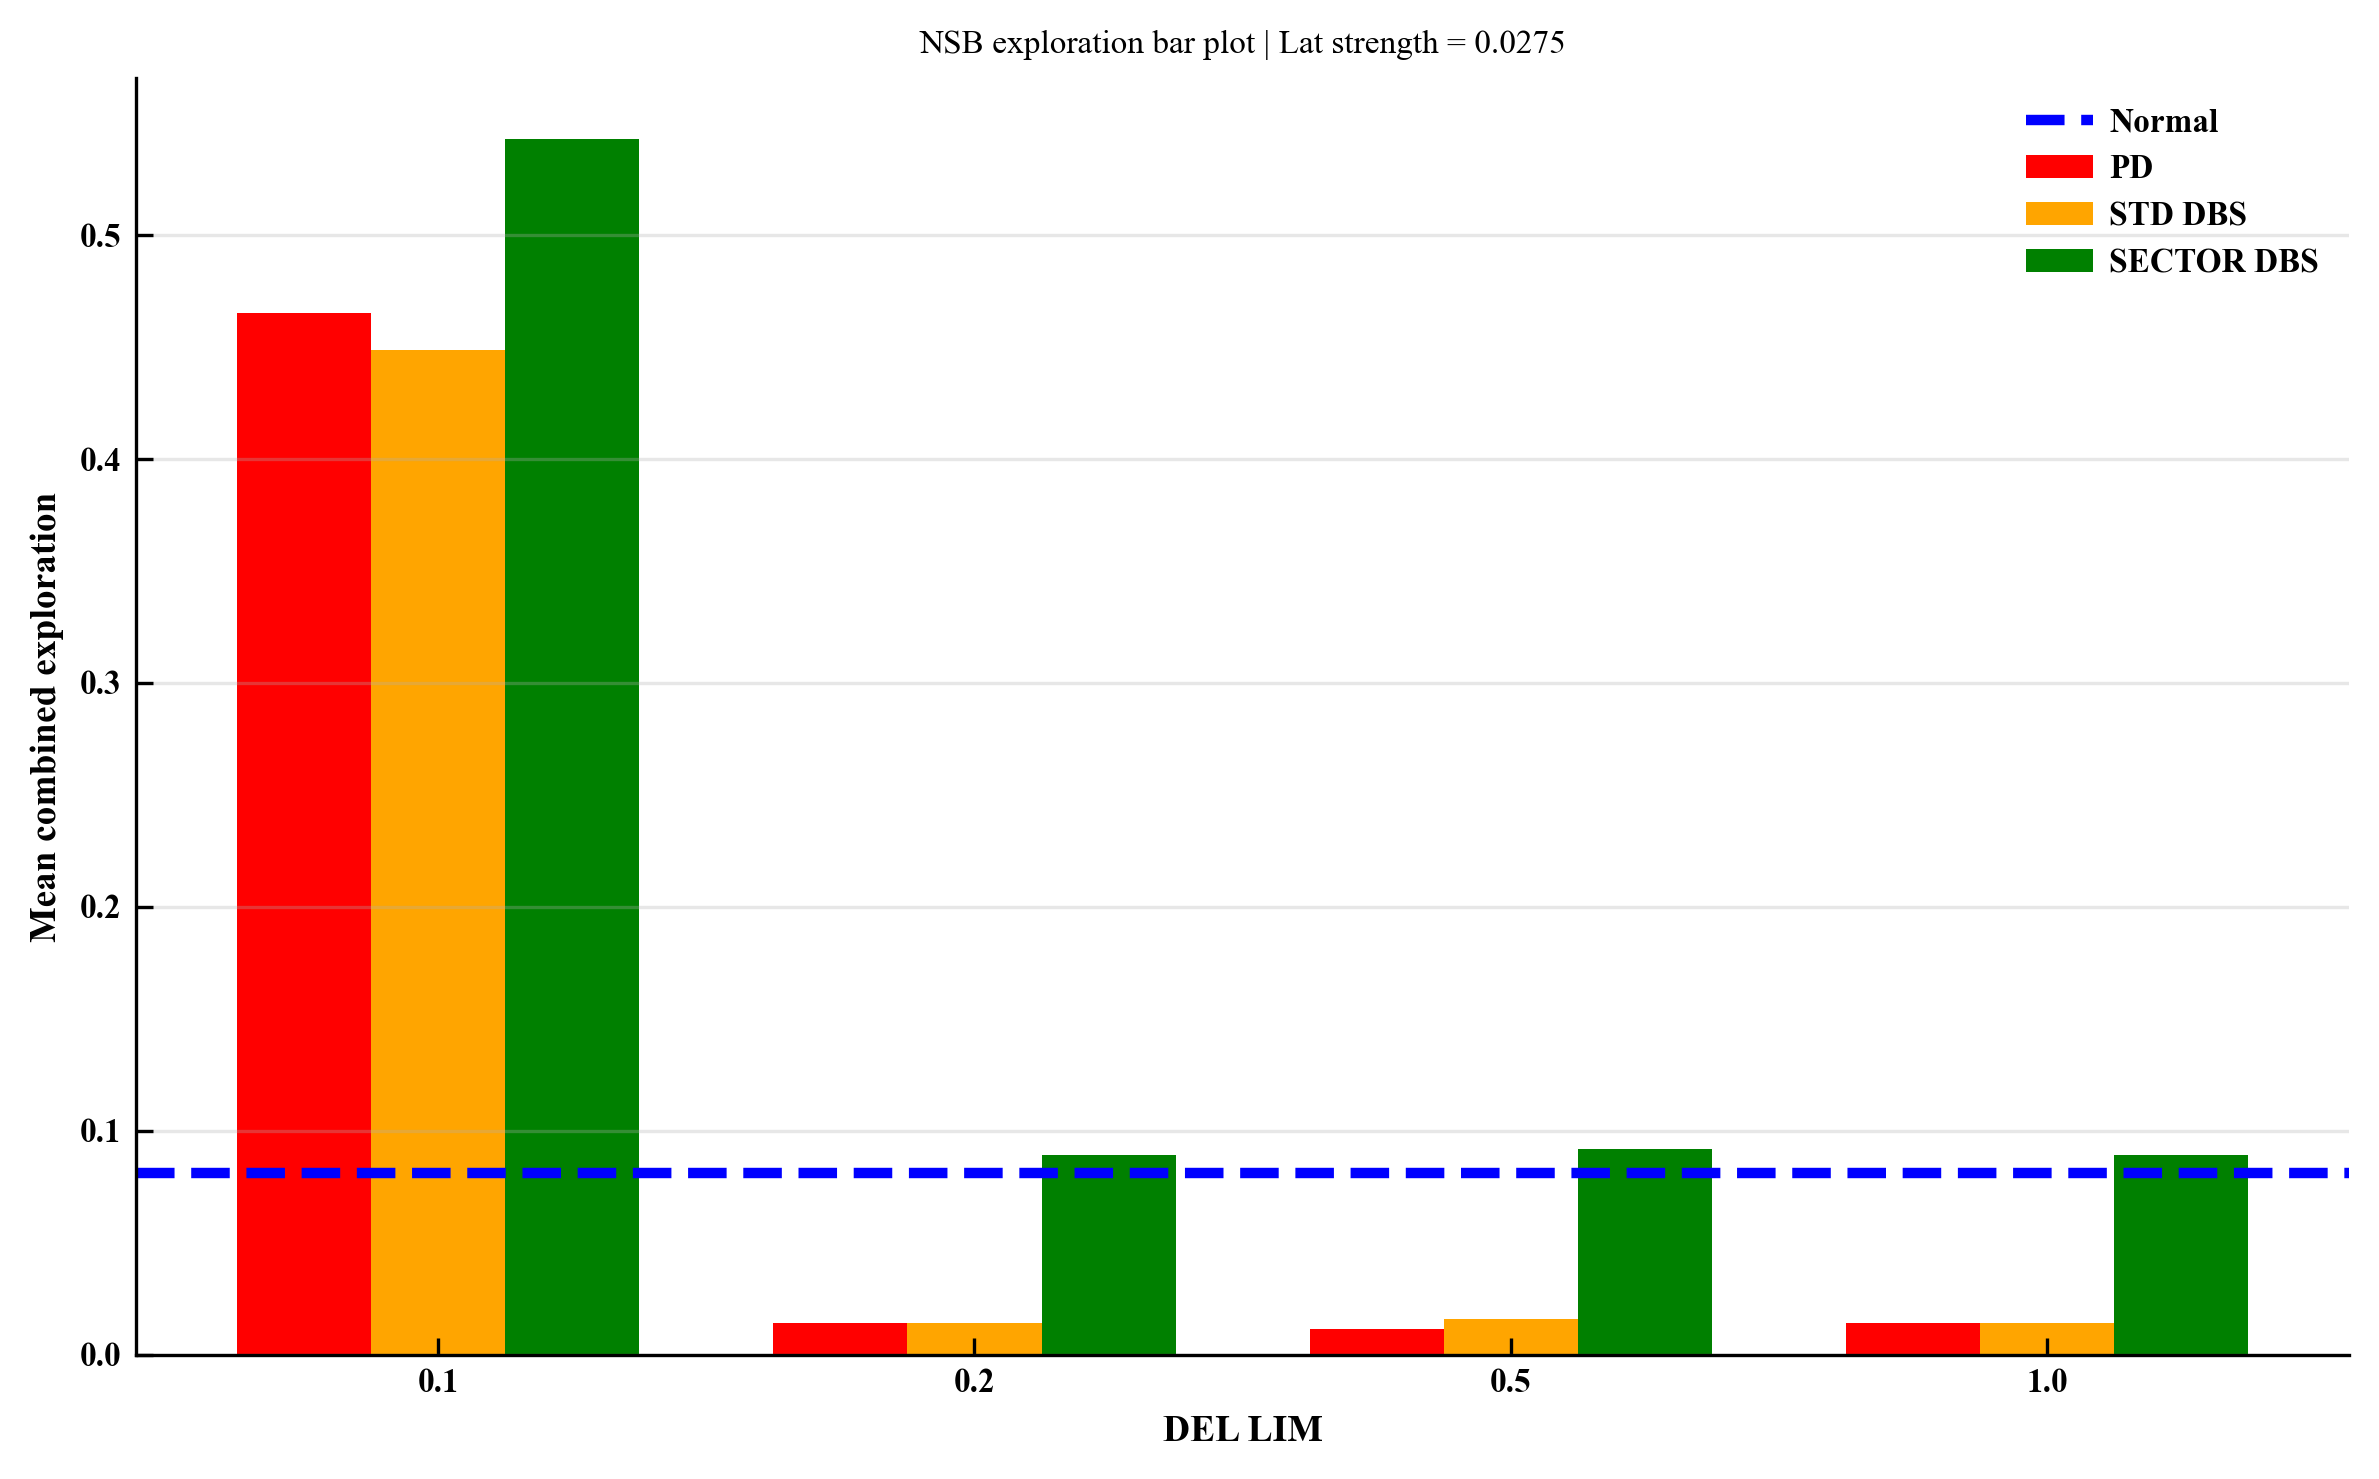

In [34]:
# ============================================================
# Bar plot for one lateral strength
# x-axis = DEL LIM
# bars = PD, STD DBS, SECTOR DBS
# y-axis = Mean combined exploration
# ============================================================

selected_lat_strength = 0.0275   # change this to 0.0325, 0.0375, 0.0425, 0.0475 etc.

condition_keys = ["PD", "STD_DBS", "SECTOR_DBS"]

condition_labels = {
    "PD": "PD",
    "STD_DBS": "STD DBS",
    "SECTOR_DBS": "SECTOR DBS"
}

condition_colors = {
    "PD": "red",
    "STD_DBS": "orange",
    "SECTOR_DBS": "green"
}

# Filter for one lateral strength
temp_lat = results_df[results_df["Lat_strength"] == selected_lat_strength].copy()

# Sort DEL LIM values
del_lims = sorted(temp_lat["Del_lim"].unique())

x = np.arange(len(del_lims))
bar_width = 0.25

plt.figure(figsize=(8, 5))

for i, condition_key in enumerate(condition_keys):

    temp_condition = temp_lat[temp_lat["Condition"] == condition_key]
    temp_condition = temp_condition.sort_values("Del_lim")

    y_values = []

    for del_lim in del_lims:
        value = temp_condition[temp_condition["Del_lim"] == del_lim]["Mean_combined"].values
        if len(value) > 0:
            y_values.append(value[0])
        else:
            y_values.append(np.nan)

    plt.bar(
        x + (i - 1) * bar_width,
        y_values,
        width=bar_width,
        color=condition_colors[condition_key],
        label=condition_labels[condition_key]
    )

# Normal baseline
plt.axhline(
    normal_mean_combined,
    linestyle="--",
    linewidth=2.5,
    color="blue",
    label="Normal"
)

plt.xlabel("DEL LIM")
plt.ylabel("Mean combined exploration")
plt.title(f"NSB exploration bar plot | Lat strength = {selected_lat_strength}")

plt.xticks(x, del_lims)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# NSB V2

In [37]:
data_folder = os.path.join(
    project_root,
    "results",
    "decision_making_tasks",
    "data",
    "non_stationary_bandits"
)

lat_files = sorted(glob.glob(
    os.path.join(data_folder, "non_stationary_bandits_v2_data_lat_*.pkl")
))

print("Found lateral strength files:")
for f in lat_files:
    print(os.path.basename(f))


# ============================================================
# Extract lateral strength from filename
# Example:
# non_stationary_bandits_v1_data_lat_0_0275.pkl -> 0.0275
# ============================================================

def extract_lat_strength_from_filename(file_path):
    fname = os.path.basename(file_path)
    match = re.search(r"lat_(\d+)_(\d+)", fname)

    if match is None:
        raise ValueError(f"Could not extract lateral strength from filename: {fname}")

    return float(match.group(1) + "." + match.group(2))


def to_float(x):
    if torch.is_tensor(x):
        return float(x.detach().cpu().item())
    if isinstance(x, np.ndarray):
        return float(x.item())
    return float(x)


# ============================================================
# Load normal baseline
# ============================================================

data_normal_file_v1 = os.path.join(
    data_folder,
    "non_stationary_bandits_v1_normal.pkl"
)

with open(data_normal_file_v1, "rb") as f:
    data_normal_v1 = pickle.load(f)

exp_res_normal = compute_exploration_metrics(
    data_normal_v1["ARM_CHOSEN_MONITOR"],
    n_arms=3,
    window_size=15,
    alpha=0.7
)

normal_mean_combined = torch.mean(exp_res_normal["mean_combined"]).item()
normal_mean_entropy = torch.mean(exp_res_normal["mean_entropy"]).item()
normal_mean_switching = torch.mean(exp_res_normal["mean_switching"]).item()

print("\nNormal baseline:")
print("Mean combined :", normal_mean_combined)
print("Mean entropy  :", normal_mean_entropy)
print("Mean switching:", normal_mean_switching)


# ============================================================
# Helper to extract ARM_MONITOR for each DEL_LIM
# Expected structure:
# data_all_NSB["ARM_MONITOR"]["PD"]["DEL_LIM_ARR[0]"]
# ============================================================

def get_arm_monitor_for_del_lim(data, condition_key, del_idx, del_value=None):
    condition_data = data["ARM_MONITOR"][condition_key]

    possible_keys = [
        f"DEL_LIM_ARR[{del_idx}]",
        str(del_idx),
        del_idx
    ]

    if del_value is not None:
        possible_keys.extend([
            str(del_value),
            str(to_float(del_value)),
            to_float(del_value)
        ])

    for key in possible_keys:
        if key in condition_data:
            return condition_data[key]

    raise KeyError(
        f"Could not find DEL_LIM for condition={condition_key}, "
        f"del_idx={del_idx}, del_value={del_value}. "
        f"Available keys: {list(condition_data.keys())}"
    )


# ============================================================
# Correct condition keys and fixed colors
# ============================================================

condition_keys = ["PD", "STD_DBS", "SECTOR_DBS"]

condition_labels = {
    "PD": "PD",
    "STD_DBS": "STD DBS",
    "SECTOR_DBS": "SECTOR DBS"
}

condition_colors = {
    "PD": "red",
    "STD_DBS": "orange",
    "SECTOR_DBS": "green"
}


# ============================================================
# Compute exploration metrics across all lateral strength files
# ============================================================

results = []

for file_path in lat_files:

    lat_strength = extract_lat_strength_from_filename(file_path)

    with open(file_path, "rb") as f:
        data_all_NSB = pickle.load(f)

    print("\nProcessing:", os.path.basename(file_path))
    print("Lat strength:", lat_strength)
    print("Available ARM_MONITOR keys:", list(data_all_NSB["ARM_MONITOR"].keys()))

    del_lim_arr = data_all_NSB["DEL_LIM_ARR"]

    for condition_key in condition_keys:

        if condition_key not in data_all_NSB["ARM_MONITOR"]:
            print(f"Skipping {condition_key}, not found.")
            continue

        for del_idx, del_lim in enumerate(del_lim_arr):

            arm_monitor = get_arm_monitor_for_del_lim(
                data=data_all_NSB,
                condition_key=condition_key,
                del_idx=del_idx,
                del_value=del_lim
            )

            exp_res = compute_exploration_metrics(
                arm_monitor,
                n_arms=3,
                window_size=15,
                alpha=0.7
            )

            mean_combined = torch.mean(exp_res["mean_combined"]).item()
            mean_entropy = torch.mean(exp_res["mean_entropy"]).item()
            mean_switching = torch.mean(exp_res["mean_switching"]).item()

            results.append({
                "Condition": condition_key,
                "Condition_label": condition_labels[condition_key],
                "Lat_strength": lat_strength,
                "Del_lim": to_float(del_lim),
                "Mean_combined": mean_combined,
                "Mean_entropy": mean_entropy,
                "Mean_switching": mean_switching
            })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by=["Lat_strength", "Condition", "Del_lim"]
).reset_index(drop=True)

display(results_df)

Found lateral strength files:
non_stationary_bandits_v2_data_lat_0_0275.pkl
non_stationary_bandits_v2_data_lat_0_0325.pkl
non_stationary_bandits_v2_data_lat_0_0375.pkl
non_stationary_bandits_v2_data_lat_0_0425.pkl
non_stationary_bandits_v2_data_lat_0_0475.pkl

Normal baseline:
Mean combined : 0.08129611611366272
Mean entropy  : 0.09494012594223022
Mean switching: 0.04946012794971466

Processing: non_stationary_bandits_v2_data_lat_0_0275.pkl
Lat strength: 0.0275
Available ARM_MONITOR keys: ['PD', 'STD_DBS', 'SECTOR_DBS']

Processing: non_stationary_bandits_v2_data_lat_0_0325.pkl
Lat strength: 0.0325
Available ARM_MONITOR keys: ['PD', 'STD_DBS', 'SECTOR_DBS']

Processing: non_stationary_bandits_v2_data_lat_0_0375.pkl
Lat strength: 0.0375
Available ARM_MONITOR keys: ['PD', 'STD_DBS', 'SECTOR_DBS']

Processing: non_stationary_bandits_v2_data_lat_0_0425.pkl
Lat strength: 0.0425
Available ARM_MONITOR keys: ['PD', 'STD_DBS', 'SECTOR_DBS']

Processing: non_stationary_bandits_v2_data_lat_0_0475

,Condition,Condition_label,Lat_strength,Del_lim,Mean_combined,Mean_entropy,Mean_switching
0,PD,PD,0.0275,0.1,0.435641,0.494787,0.297633
1,PD,PD,0.0275,0.2,0.031674,0.040044,0.012143
2,PD,PD,0.0275,0.5,0.046300,0.057987,0.019028
3,PD,PD,0.0275,1.0,0.031674,0.040044,0.012143
4,SECTOR_DBS,SECTOR DBS,0.0275,0.1,0.709881,0.788663,0.526055
5,SECTOR_DBS,SECTOR DBS,0.0275,0.2,0.116665,0.140502,0.061047
6,SECTOR_DBS,SECTOR DBS,0.0275,0.5,0.132172,0.158145,0.071570
7,SECTOR_DBS,SECTOR DBS,0.0275,1.0,0.116665,0.140502,0.061047
8,STD_DBS,STD DBS,0.0275,0.1,0.530310,0.593914,0.381902
9,STD_DBS,STD DBS,0.0275,0.2,0.054260,0.067704,0.022890


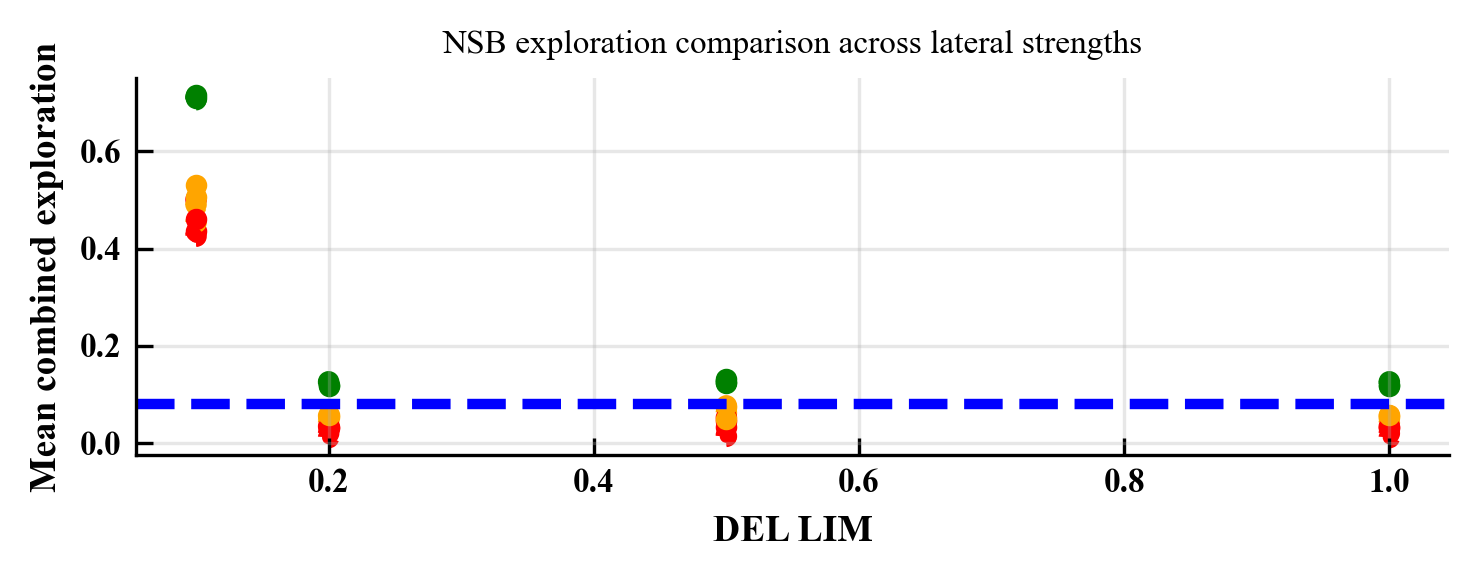

In [38]:
line_styles = ["-", "--", "-.", ":"]

plt.figure(figsize=(5,2))

lat_strengths = sorted(results_df["Lat_strength"].unique())

for lat_idx, lat_strength in enumerate(lat_strengths):

    temp_lat = results_df[results_df["Lat_strength"] == lat_strength]
    linestyle = line_styles[lat_idx % len(line_styles)]

    for condition_key in condition_keys:

        temp = temp_lat[temp_lat["Condition"] == condition_key]
        temp = temp.sort_values("Del_lim")

        if len(temp) == 0:
            continue

        plt.scatter(
            temp["Del_lim"],
            temp["Mean_combined"],
            marker="o",
            s = 10,
            linewidth=2,
            linestyle=linestyle,
            color=condition_colors[condition_key],
            label=f"{condition_labels[condition_key]} | Lat={lat_strength}"
        )

plt.axhline(
    normal_mean_combined,
    linestyle="--",
    linewidth=2.5,
    color="blue",
    label="Normal"
)

plt.xlabel("DEL LIM")
plt.ylabel("Mean combined exploration")
plt.title("NSB exploration comparison across lateral strengths")
# plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

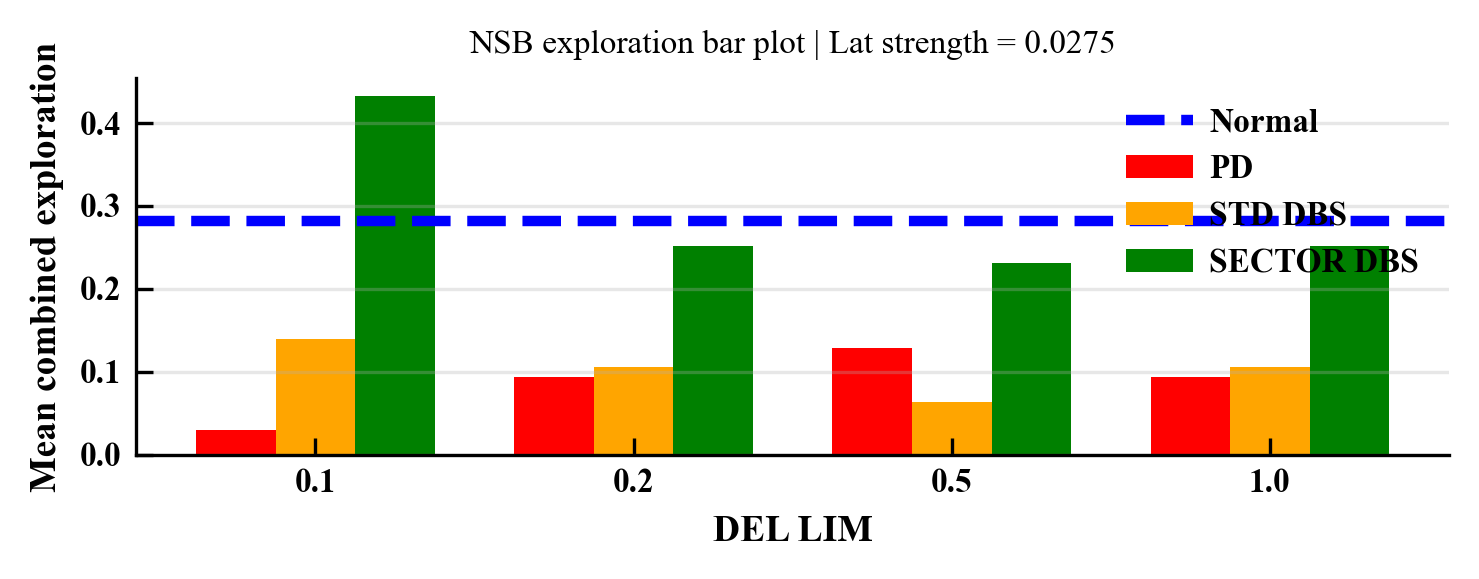

In [47]:
# ============================================================
# Bar plot for one lateral strength
# x-axis = DEL LIM
# bars = PD, STD DBS, SECTOR DBS
# y-axis = Mean combined exploration
# ============================================================

selected_lat_strength = 0.0275   # change this to 0.0325, 0.0375, 0.0425, 0.0475 etc.

condition_keys = ["PD", "STD_DBS", "SECTOR_DBS"]

condition_labels = {
    "PD": "PD",
    "STD_DBS": "STD DBS",
    "SECTOR_DBS": "SECTOR DBS"
}

condition_colors = {
    "PD": "red",
    "STD_DBS": "orange",
    "SECTOR_DBS": "green"
}

# Filter for one lateral strength
temp_lat = results_df[results_df["Lat_strength"] == selected_lat_strength].copy()

# Sort DEL LIM values
del_lims = sorted(temp_lat["Del_lim"].unique())

x = np.arange(len(del_lims))
bar_width = 0.25

plt.figure(figsize=(5, 2))

for i, condition_key in enumerate(condition_keys):

    temp_condition = temp_lat[temp_lat["Condition"] == condition_key]
    temp_condition = temp_condition.sort_values("Del_lim")

    y_values = []

    for del_lim in del_lims:
        value = temp_condition[temp_condition["Del_lim"] == del_lim]["Mean_combined"].values
        if len(value) > 0:
            y_values.append(value[0])
        else:
            y_values.append(np.nan)

    plt.bar(
        x + (i - 1) * bar_width,
        y_values,
        width=bar_width,
        color=condition_colors[condition_key],
        label=condition_labels[condition_key]
    )

# Normal baseline
plt.axhline(
    normal_mean_combined,
    linestyle="--",
    linewidth=2.5,
    color="blue",
    label="Normal"
)

plt.xlabel("DEL LIM")
plt.ylabel("Mean combined exploration")
plt.title(f"NSB exploration bar plot | Lat strength = {selected_lat_strength}")

plt.xticks(x, del_lims)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## RB

In [41]:


rb_data_folder = os.path.join(
    project_root,
    "results",
    "decision_making_tasks",
    "data",
    "restless_bandits"
)

# ============================================================
# Read only main lateral strength files
# Excludes:
# restless_bandits_data_lat_0_0275_1.pkl
# restless_bandits_data_lat_0_0275_2.pkl
# ============================================================

all_rb_lat_files = glob.glob(
    os.path.join(rb_data_folder, "restless_bandits_data_lat_*.pkl")
)

rb_lat_files = sorted([
    f for f in all_rb_lat_files
    if re.fullmatch(
        r"restless_bandits_data_lat_\d+_\d+\.pkl",
        os.path.basename(f)
    )
])

print("Using RB lateral strength files:")
for f in rb_lat_files:
    print(os.path.basename(f))


# ============================================================
# Extract lateral strength from filename
# Example:
# restless_bandits_data_lat_0_0275.pkl -> 0.0275
# ============================================================

def extract_lat_strength_from_filename(file_path):
    fname = os.path.basename(file_path)
    match = re.search(r"lat_(\d+)_(\d+)", fname)

    if match is None:
        raise ValueError(f"Could not extract lateral strength from filename: {fname}")

    return float(match.group(1) + "." + match.group(2))


def to_float(x):
    if torch.is_tensor(x):
        return float(x.detach().cpu().item())
    if isinstance(x, np.ndarray):
        return float(x.item())
    return float(x)


# ============================================================
# Load RB normal baseline
# ============================================================

data_file_normal = os.path.join(
    rb_data_folder,
    "normal_data_1.pkl"
)

with open(data_file_normal, "rb") as f:
    normal_data = pickle.load(f)

print("\nNormal RB keys:", normal_data.keys())

exp_res_normal = compute_exploration_metrics(
    normal_data["arm_chosen_monitor"],
    n_arms=3,
    window_size=15,
    alpha=0.7
)

normal_mean_combined = torch.mean(exp_res_normal["mean_combined"]).item()
normal_mean_entropy = torch.mean(exp_res_normal["mean_entropy"]).item()
normal_mean_switching = torch.mean(exp_res_normal["mean_switching"]).item()

print("\nRB Normal baseline:")
print("Mean combined :", normal_mean_combined)
print("Mean entropy  :", normal_mean_entropy)
print("Mean switching:", normal_mean_switching)


# ============================================================
# Helper to extract ARM_MONITOR for each DEL LIM
# Expected:
# data_RB["ARM_MONITOR"]["PD"]["DEL_LIM_ARR[0]"]
# ============================================================

def get_arm_monitor_for_del_lim(data, condition_key, del_idx, del_value=None):
    condition_data = data["ARM_MONITOR"][condition_key]

    possible_keys = [
        f"DEL_LIM_ARR[{del_idx}]",
        str(del_idx),
        del_idx
    ]

    if del_value is not None:
        possible_keys.extend([
            str(del_value),
            str(to_float(del_value)),
            to_float(del_value)
        ])

    for key in possible_keys:
        if key in condition_data:
            return condition_data[key]

    raise KeyError(
        f"Could not find DEL_LIM for condition={condition_key}, "
        f"del_idx={del_idx}, del_value={del_value}. "
        f"Available keys: {list(condition_data.keys())}"
    )


# ============================================================
# Condition keys and colors
# ============================================================

condition_keys = ["PD", "STD_DBS", "SECTOR_DBS"]

condition_labels = {
    "PD": "PD",
    "STD_DBS": "STD DBS",
    "SECTOR_DBS": "SECTOR DBS"
}

condition_colors = {
    "PD": "red",
    "STD_DBS": "orange",
    "SECTOR_DBS": "green"
}


# ============================================================
# Compute exploration metrics for RB
# No aggregation
# Only main lat files are used
# ============================================================

results = []

for file_path in rb_lat_files:

    lat_strength = extract_lat_strength_from_filename(file_path)

    with open(file_path, "rb") as f:
        data_RB = pickle.load(f)

    print("\nProcessing:", os.path.basename(file_path))
    print("Lat strength:", lat_strength)
    print("RB keys:", data_RB.keys())
    print("Available ARM_MONITOR keys:", list(data_RB["ARM_MONITOR"].keys()))

    del_lim_arr = data_RB["DEL_LIM_ARR"]

    for condition_key in condition_keys:

        if condition_key not in data_RB["ARM_MONITOR"]:
            print(f"Skipping {condition_key}, not found.")
            continue

        for del_idx, del_lim in enumerate(del_lim_arr):

            arm_monitor = get_arm_monitor_for_del_lim(
                data=data_RB,
                condition_key=condition_key,
                del_idx=del_idx,
                del_value=del_lim
            )

            exp_res = compute_exploration_metrics(
                arm_monitor,
                n_arms=3,
                window_size=15,
                alpha=0.7
            )

            mean_combined = torch.mean(exp_res["mean_combined"]).item()
            mean_entropy = torch.mean(exp_res["mean_entropy"]).item()
            mean_switching = torch.mean(exp_res["mean_switching"]).item()

            results.append({
                "Condition": condition_key,
                "Condition_label": condition_labels[condition_key],
                "Lat_strength": lat_strength,
                "Del_lim": to_float(del_lim),
                "Mean_combined": mean_combined,
                "Mean_entropy": mean_entropy,
                "Mean_switching": mean_switching
            })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by=["Lat_strength", "Condition", "Del_lim"]
).reset_index(drop=True)

display(results_df)

Using RB lateral strength files:
restless_bandits_data_lat_0_0275.pkl
restless_bandits_data_lat_0_0325.pkl
restless_bandits_data_lat_0_0375.pkl
restless_bandits_data_lat_0_0425.pkl
restless_bandits_data_lat_0_0475.pkl

Normal RB keys: dict_keys(['arm_chosen_monitor', 'reward_monitor', 'dp_monitor', 'ip_monitor', 'arm_tracker_full', 'prob', 'mean_prob'])

RB Normal baseline:
Mean combined : 0.2813698351383209
Mean entropy  : 0.341571569442749
Mean switching: 0.14089909195899963

Processing: restless_bandits_data_lat_0_0275.pkl
Lat strength: 0.0275
RB keys: dict_keys(['DEL_LIM_ARR', 'TYPE', 'ARM_MONITOR', 'LAT_STRENGTH', 'ARM_TRACKER', 'REWARD_MONITOR', 'PROB_OPTIMAL_MONITOR', 'MEAN_PROB_MONITOR'])
Available ARM_MONITOR keys: ['PD', 'STD_DBS', 'SECTOR_DBS']

Processing: restless_bandits_data_lat_0_0325.pkl
Lat strength: 0.0325
RB keys: dict_keys(['DEL_LIM_ARR', 'TYPE', 'ARM_MONITOR', 'LAT_STRENGTH', 'ARM_TRACKER', 'REWARD_MONITOR', 'PROB_OPTIMAL_MONITOR', 'MEAN_PROB_MONITOR'])
Available 

,Condition,Condition_label,Lat_strength,Del_lim,Mean_combined,Mean_entropy,Mean_switching
0,PD,PD,0.0275,0.1,0.030371,0.039591,0.008856
1,PD,PD,0.0275,0.2,0.093161,0.118341,0.034408
2,PD,PD,0.0275,0.5,0.128600,0.162523,0.049446
3,PD,PD,0.0275,1.0,0.093161,0.118341,0.034408
4,SECTOR_DBS,SECTOR DBS,0.0275,0.1,0.432695,0.505674,0.262410
5,SECTOR_DBS,SECTOR DBS,0.0275,0.2,0.251305,0.304911,0.126224
6,SECTOR_DBS,SECTOR DBS,0.0275,0.5,0.230928,0.280569,0.115097
7,SECTOR_DBS,SECTOR DBS,0.0275,1.0,0.251305,0.304911,0.126224
8,STD_DBS,STD DBS,0.0275,0.1,0.139690,0.169801,0.069431
9,STD_DBS,STD DBS,0.0275,0.2,0.106110,0.135009,0.038679


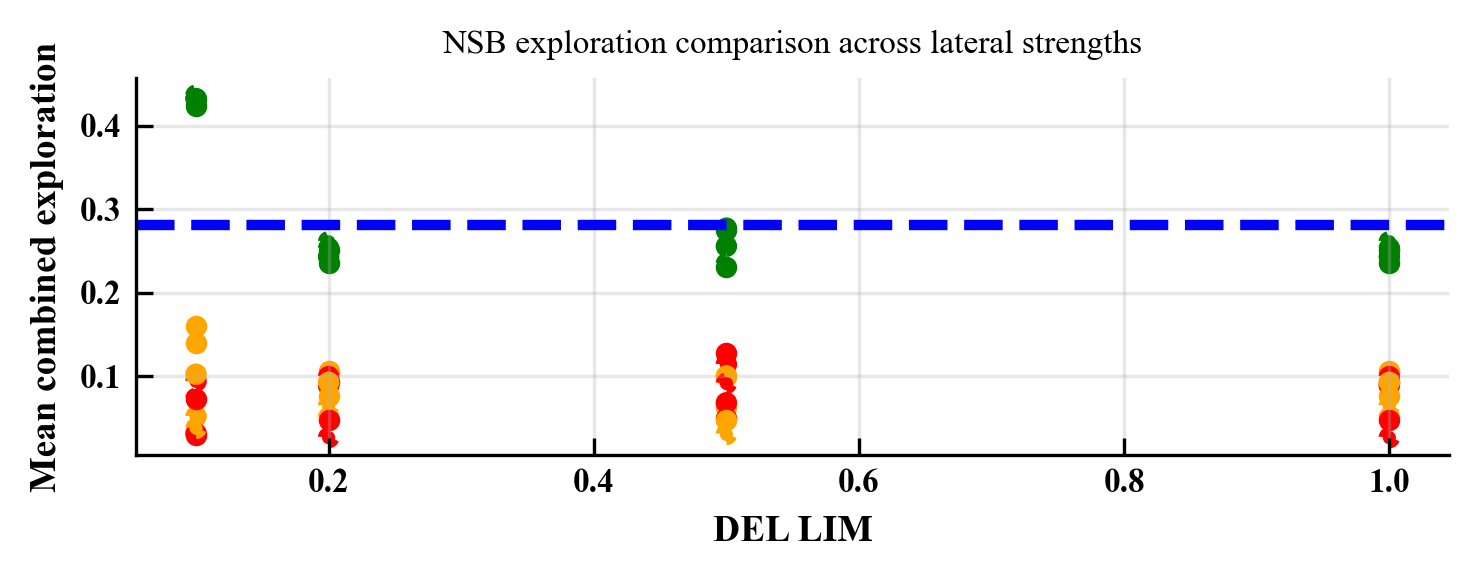

In [42]:
line_styles = ["-", "--", "-.", ":"]

plt.figure(figsize=(5,2))

lat_strengths = sorted(results_df["Lat_strength"].unique())

for lat_idx, lat_strength in enumerate(lat_strengths):

    temp_lat = results_df[results_df["Lat_strength"] == lat_strength]
    linestyle = line_styles[lat_idx % len(line_styles)]

    for condition_key in condition_keys:

        temp = temp_lat[temp_lat["Condition"] == condition_key]
        temp = temp.sort_values("Del_lim")

        if len(temp) == 0:
            continue

        plt.scatter(
            temp["Del_lim"],
            temp["Mean_combined"],
            marker="o",
            s = 10,
            linewidth=2,
            linestyle=linestyle,
            color=condition_colors[condition_key],
            label=f"{condition_labels[condition_key]} | Lat={lat_strength}"
        )

plt.axhline(
    normal_mean_combined,
    linestyle="--",
    linewidth=2.5,
    color="blue",
    label="Normal"
)

plt.xlabel("DEL LIM")
plt.ylabel("Mean combined exploration")
plt.title("NSB exploration comparison across lateral strengths")
# plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

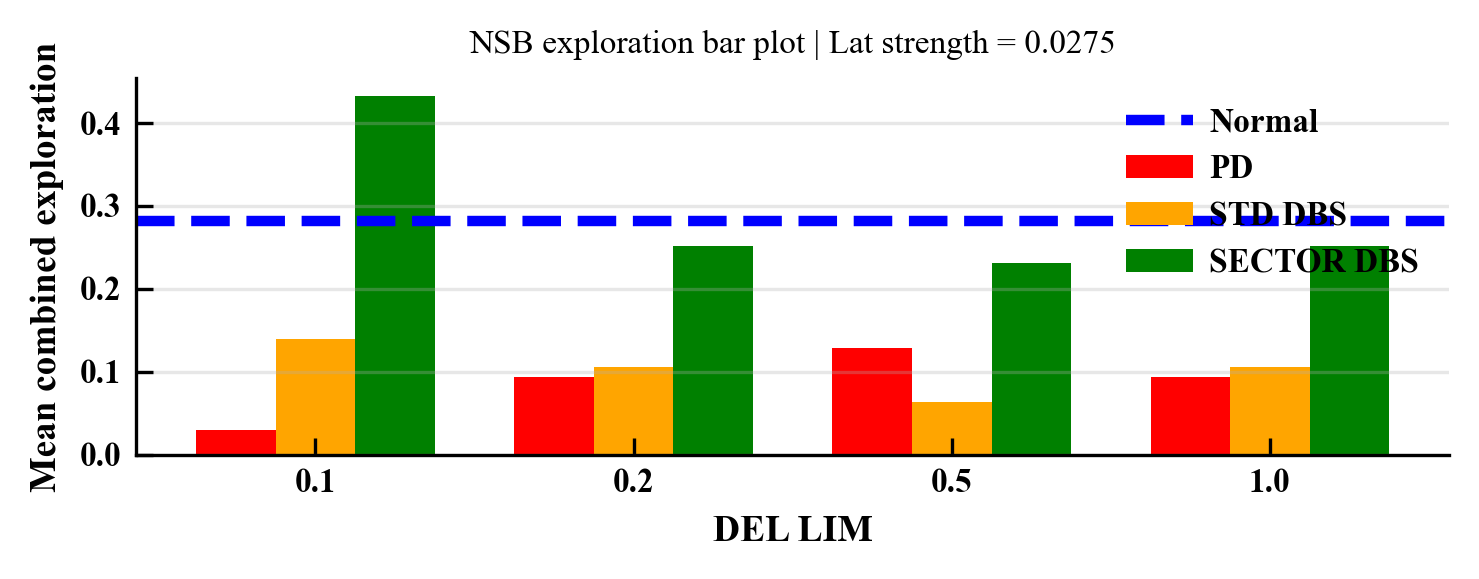

In [46]:
# ============================================================
# Bar plot for one lateral strength
# x-axis = DEL LIM
# bars = PD, STD DBS, SECTOR DBS
# y-axis = Mean combined exploration
# ============================================================

selected_lat_strength = 0.0275   # change this to 0.0325, 0.0375, 0.0425, 0.0475 etc.

condition_keys = ["PD", "STD_DBS", "SECTOR_DBS"]

condition_labels = {
    "PD": "PD",
    "STD_DBS": "STD DBS",
    "SECTOR_DBS": "SECTOR DBS"
}

condition_colors = {
    "PD": "red",
    "STD_DBS": "orange",
    "SECTOR_DBS": "green"
}

# Filter for one lateral strength
temp_lat = results_df[results_df["Lat_strength"] == selected_lat_strength].copy()

# Sort DEL LIM values
del_lims = sorted(temp_lat["Del_lim"].unique())

x = np.arange(len(del_lims))
bar_width = 0.25

plt.figure(figsize=(5,2))

for i, condition_key in enumerate(condition_keys):

    temp_condition = temp_lat[temp_lat["Condition"] == condition_key]
    temp_condition = temp_condition.sort_values("Del_lim")

    y_values = []

    for del_lim in del_lims:
        value = temp_condition[temp_condition["Del_lim"] == del_lim]["Mean_combined"].values
        if len(value) > 0:
            y_values.append(value[0])
        else:
            y_values.append(np.nan)

    plt.bar(
        x + (i - 1) * bar_width,
        y_values,
        width=bar_width,
        color=condition_colors[condition_key],
        label=condition_labels[condition_key]
    )

# Normal baseline
plt.axhline(
    normal_mean_combined,
    linestyle="--",
    linewidth=2.5,
    color="blue",
    label="Normal"
)

plt.xlabel("DEL LIM")
plt.ylabel("Mean combined exploration")
plt.title(f"NSB exploration bar plot | Lat strength = {selected_lat_strength}")

plt.xticks(x, del_lims)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## IGT

In [49]:

igt_data_folder = os.path.join(
    project_root,
    "results",
    "decision_making_tasks",
    "data",
    "igt"
)

# ============================================================
# Read all IGT lateral strength files
# Example:
# igt_data_lat_0_0275.pkl
# ============================================================

igt_lat_files = sorted(glob.glob(
    os.path.join(igt_data_folder, "igt_data_lat_*.pkl")
))

print("Found IGT lateral strength files:")
for f in igt_lat_files:
    print(os.path.basename(f))


# ============================================================
# Helper functions
# ============================================================

def extract_lat_strength_from_filename(file_path):
    """
    Example:
    igt_data_lat_0_0275.pkl -> 0.0275
    """
    fname = os.path.basename(file_path)
    match = re.search(r"lat_(\d+)_(\d+)", fname)

    if match is None:
        raise ValueError(f"Could not extract lateral strength from filename: {fname}")

    return float(match.group(1) + "." + match.group(2))


def to_float(x):
    if torch.is_tensor(x):
        return float(x.detach().cpu().item())
    if isinstance(x, np.ndarray):
        return float(x.item())
    return float(x)


def get_by_del_lim(condition_data, del_idx, del_value):
    """
    Works for float keys like 0.1, 0.2, 0.8, 1.0
    and also string/index keys if present.
    """

    possible_keys = [
        del_value,
        to_float(del_value),
        str(del_value),
        str(to_float(del_value)),
        f"DEL_LIM_ARR[{del_idx}]",
        str(del_idx),
        del_idx
    ]

    for key in possible_keys:
        if key in condition_data:
            return condition_data[key]

    raise KeyError(
        f"Could not find DEL_LIM={del_value}, del_idx={del_idx}. "
        f"Available keys: {list(condition_data.keys())}"
    )


# ============================================================
# Load IGT normal baseline
# ============================================================

# data_normal_file = os.path.join(
#     igt_data_folder,
#     "igt_data_normal.pkl"
# )

# with open(data_normal_file, "rb") as f:
#     data_normal = pickle.load(f)

# print("\nNormal IGT keys:", data_normal.keys())

# # Try common normal arm-monitor keys
# if "ARM_MONITOR" in data_normal:
#     normal_arm_monitor = data_normal["ARM_MONITOR"]
# elif "ARM_CHOSEN_MONITOR" in data_normal:
#     normal_arm_monitor = data_normal["ARM_CHOSEN_MONITOR"]
# else:
#     raise KeyError(
#         "Could not find normal arm monitor. "
#         f"Available keys: {list(data_normal.keys())}"
#     )

# exp_res_normal = compute_exploration_metrics(
#     normal_arm_monitor,
#     n_arms=4,
#     window_size=15,
#     alpha=0.7
# )

# normal_mean_combined = torch.mean(exp_res_normal["mean_combined"]).item()
# normal_mean_entropy = torch.mean(exp_res_normal["mean_entropy"]).item()
# normal_mean_switching = torch.mean(exp_res_normal["mean_switching"]).item()
# ============================================================
# IGT normal baseline
# Data missing in file, so using fixed normal value
# ============================================================

normal_mean_combined = 0.17
normal_mean_entropy = np.nan
normal_mean_switching = np.nan

print("\nIGT Normal baseline:")
print("Mean combined :", normal_mean_combined)
print("Mean entropy  :", normal_mean_entropy)
print("Mean switching:", normal_mean_switching)



# ============================================================
# Condition keys and colors
# ============================================================

condition_keys = ["PD", "STD_DBS", "SECTOR_DBS"]

condition_labels = {
    "PD": "PD",
    "STD_DBS": "STD DBS",
    "SECTOR_DBS": "SECTOR DBS"
}

condition_colors = {
    "PD": "red",
    "STD_DBS": "orange",
    "SECTOR_DBS": "green"
}


# ============================================================
# Compute exploration metrics for all IGT lateral strength files
# ============================================================

results = []

for file_path in igt_lat_files:

    lat_strength = extract_lat_strength_from_filename(file_path)

    with open(file_path, "rb") as f:
        data_IGT = pickle.load(f)

    print("\nProcessing:", os.path.basename(file_path))
    print("Lat strength:", lat_strength)
    print("IGT keys:", data_IGT.keys())
    print("Available ARM_MONITOR keys:", list(data_IGT["ARM_MONITOR"].keys()))

    # Use DEL_LIM_ARR if present, otherwise use your manually specified del-lim values
    if "DEL_LIM_ARR" in data_IGT:
        del_lim_arr = data_IGT["DEL_LIM_ARR"]
    else:
        del_lim_arr = [0.1, 0.2, 0.8, 1.0]

    for condition_key in condition_keys:

        if condition_key not in data_IGT["ARM_MONITOR"]:
            print(f"Skipping {condition_key}, not found.")
            continue

        for del_idx, del_lim in enumerate(del_lim_arr):

            arm_monitor = get_by_del_lim(
                condition_data=data_IGT["ARM_MONITOR"][condition_key],
                del_idx=del_idx,
                del_value=del_lim
            )

            exp_res = compute_exploration_metrics(
                arm_monitor,
                n_arms=4,
                window_size=15,
                alpha=0.7
            )

            mean_combined = torch.mean(exp_res["mean_combined"]).item()
            mean_entropy = torch.mean(exp_res["mean_entropy"]).item()
            mean_switching = torch.mean(exp_res["mean_switching"]).item()

            # Optional: also extract IGT score and SE if present
            last_bin_igt_score = np.nan
            last_bin_se = np.nan

            if "LAST_BIN_IGT_SCORE_MONITOR" in data_IGT:
                last_bin_igt_score = get_by_del_lim(
                    condition_data=data_IGT["LAST_BIN_IGT_SCORE_MONITOR"][condition_key],
                    del_idx=del_idx,
                    del_value=del_lim
                )

            if "LAST_BIN_SE_MONITOR" in data_IGT:
                last_bin_se = get_by_del_lim(
                    condition_data=data_IGT["LAST_BIN_SE_MONITOR"][condition_key],
                    del_idx=del_idx,
                    del_value=del_lim
                )

            results.append({
                "Condition": condition_key,
                "Condition_label": condition_labels[condition_key],
                "Lat_strength": lat_strength,
                "Del_lim": to_float(del_lim),
                "Mean_combined": mean_combined,
                "Mean_entropy": mean_entropy,
                "Mean_switching": mean_switching,
                "Last_bin_IGT_score": to_float(last_bin_igt_score) if not isinstance(last_bin_igt_score, float) or not np.isnan(last_bin_igt_score) else np.nan,
                "Last_bin_SE": to_float(last_bin_se) if not isinstance(last_bin_se, float) or not np.isnan(last_bin_se) else np.nan
            })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by=["Lat_strength", "Condition", "Del_lim"]
).reset_index(drop=True)

display(results_df)

Found IGT lateral strength files:
igt_data_lat_0_0275.pkl
igt_data_lat_0_0325.pkl
igt_data_lat_0_0375.pkl
igt_data_lat_0_0425.pkl
igt_data_lat_0_0475.pkl

IGT Normal baseline:
Mean combined : 0.17
Mean entropy  : nan
Mean switching: nan

Processing: igt_data_lat_0_0275.pkl
Lat strength: 0.0275
IGT keys: dict_keys(['DEL_LIM_ARR', 'TYPE', 'ARM_MONITOR', 'LAT_STRENGTH', 'LAST_BIN_IGT_SCORE_MONITOR', 'IGT_SCORE_MONITOR', 'IGT_SE_MONITOR', 'LAST_BIN_SE_MONITOR', 'REWARD_MONITOR'])
Available ARM_MONITOR keys: ['PD', 'STD_DBS', 'SECTOR_DBS']

Processing: igt_data_lat_0_0325.pkl
Lat strength: 0.0325
IGT keys: dict_keys(['DEL_LIM_ARR', 'TYPE', 'ARM_MONITOR', 'LAT_STRENGTH', 'LAST_BIN_IGT_SCORE_MONITOR', 'IGT_SCORE_MONITOR', 'IGT_SE_MONITOR', 'LAST_BIN_SE_MONITOR', 'REWARD_MONITOR'])
Available ARM_MONITOR keys: ['PD', 'STD_DBS', 'SECTOR_DBS']

Processing: igt_data_lat_0_0375.pkl
Lat strength: 0.0375
IGT keys: dict_keys(['DEL_LIM_ARR', 'TYPE', 'ARM_MONITOR', 'LAT_STRENGTH', 'LAST_BIN_IGT_SCORE_MO

,Condition,Condition_label,Lat_strength,Del_lim,Mean_combined,Mean_entropy,Mean_switching,Last_bin_IGT_score,Last_bin_SE
0,PD,PD,0.0275,0.1,0.079333,0.102641,0.024950,-20.00,0.000000
1,PD,PD,0.0275,0.2,0.082597,0.106925,0.025831,-20.00,0.000000
2,PD,PD,0.0275,0.5,0.089746,0.117266,0.025532,-12.12,1.427244
3,PD,PD,0.0275,0.8,0.112311,0.146437,0.032683,-8.22,1.633709
4,PD,PD,0.0275,1.0,0.112376,0.146679,0.032334,-6.52,1.666211
...,...,...,...,...,...,...,...,...,...
70,STD_DBS,STD DBS,0.0475,0.1,0.079233,0.102401,0.025174,-20.00,0.000000
71,STD_DBS,STD DBS,0.0475,0.2,0.081765,0.105794,0.025698,-20.00,0.000000
72,STD_DBS,STD DBS,0.0475,0.5,0.095376,0.124661,0.027043,-13.94,1.281872
73,STD_DBS,STD DBS,0.0475,0.8,0.114676,0.150069,0.032093,-4.56,1.832166


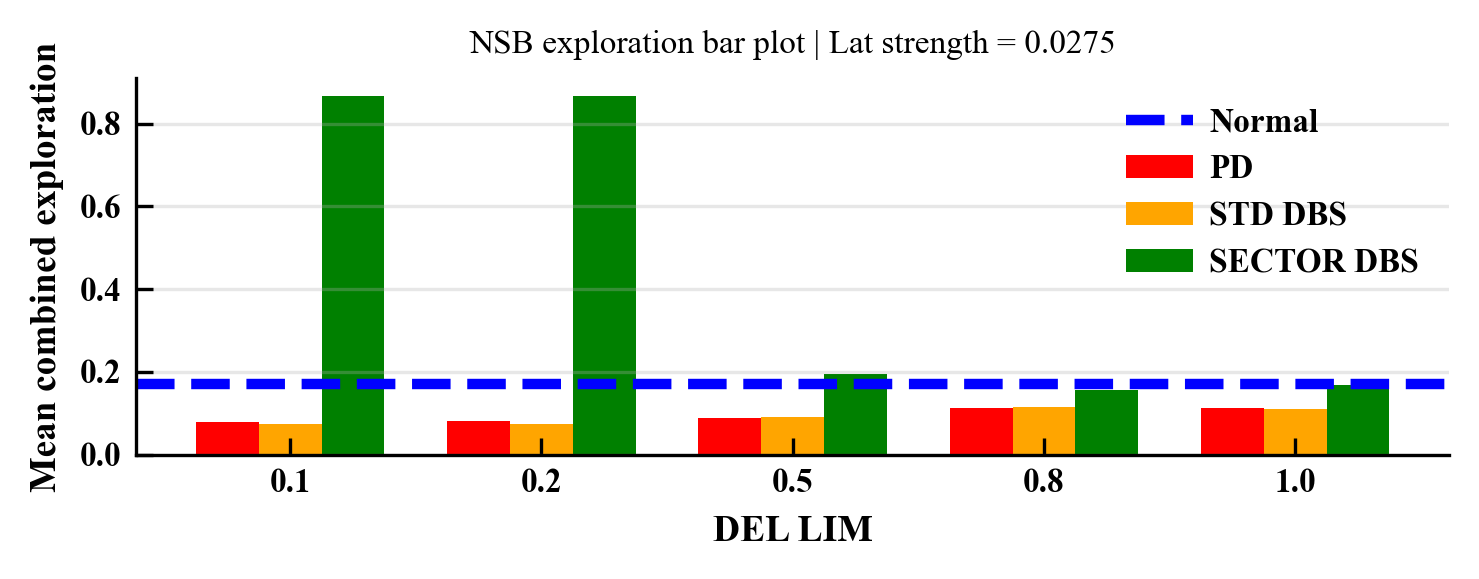

In [50]:
# ============================================================
# Bar plot for one lateral strength
# x-axis = DEL LIM
# bars = PD, STD DBS, SECTOR DBS
# y-axis = Mean combined exploration
# ============================================================

selected_lat_strength = 0.0275   # change this to 0.0325, 0.0375, 0.0425, 0.0475 etc.

condition_keys = ["PD", "STD_DBS", "SECTOR_DBS"]

condition_labels = {
    "PD": "PD",
    "STD_DBS": "STD DBS",
    "SECTOR_DBS": "SECTOR DBS"
}

condition_colors = {
    "PD": "red",
    "STD_DBS": "orange",
    "SECTOR_DBS": "green"
}

# Filter for one lateral strength
temp_lat = results_df[results_df["Lat_strength"] == selected_lat_strength].copy()

# Sort DEL LIM values
del_lims = sorted(temp_lat["Del_lim"].unique())

x = np.arange(len(del_lims))
bar_width = 0.25

plt.figure(figsize=(5,2))

for i, condition_key in enumerate(condition_keys):

    temp_condition = temp_lat[temp_lat["Condition"] == condition_key]
    temp_condition = temp_condition.sort_values("Del_lim")

    y_values = []

    for del_lim in del_lims:
        value = temp_condition[temp_condition["Del_lim"] == del_lim]["Mean_combined"].values
        if len(value) > 0:
            y_values.append(value[0])
        else:
            y_values.append(np.nan)

    plt.bar(
        x + (i - 1) * bar_width,
        y_values,
        width=bar_width,
        color=condition_colors[condition_key],
        label=condition_labels[condition_key]
    )

# Normal baseline
plt.axhline(
    normal_mean_combined,
    linestyle="--",
    linewidth=2.5,
    color="blue",
    label="Normal"
)

plt.xlabel("DEL LIM")
plt.ylabel("Mean combined exploration")
plt.title(f"NSB exploration bar plot | Lat strength = {selected_lat_strength}")

plt.xticks(x, del_lims)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

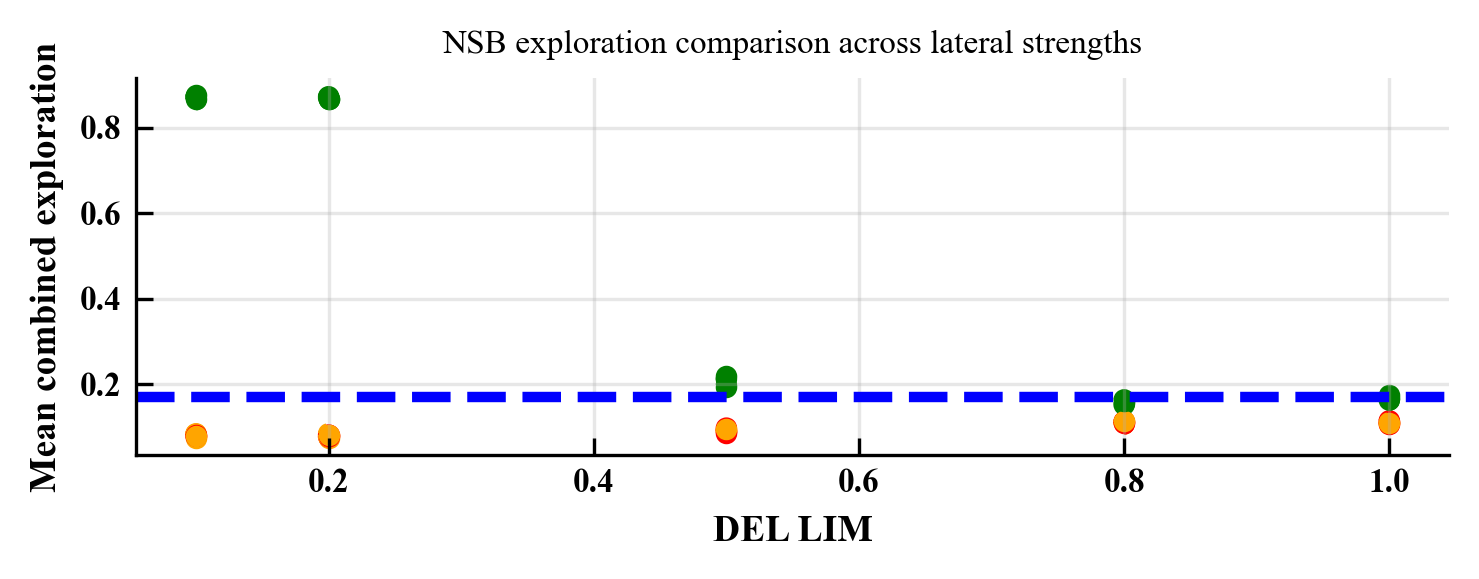

In [51]:
line_styles = ["-", "--", "-.", ":"]

plt.figure(figsize=(5,2))

lat_strengths = sorted(results_df["Lat_strength"].unique())

for lat_idx, lat_strength in enumerate(lat_strengths):

    temp_lat = results_df[results_df["Lat_strength"] == lat_strength]
    linestyle = line_styles[lat_idx % len(line_styles)]

    for condition_key in condition_keys:

        temp = temp_lat[temp_lat["Condition"] == condition_key]
        temp = temp.sort_values("Del_lim")

        if len(temp) == 0:
            continue

        plt.scatter(
            temp["Del_lim"],
            temp["Mean_combined"],
            marker="o",
            s = 10,
            linewidth=2,
            linestyle=linestyle,
            color=condition_colors[condition_key],
            label=f"{condition_labels[condition_key]} | Lat={lat_strength}"
        )

plt.axhline(
    normal_mean_combined,
    linestyle="--",
    linewidth=2.5,
    color="blue",
    label="Normal"
)

plt.xlabel("DEL LIM")
plt.ylabel("Mean combined exploration")
plt.title("NSB exploration comparison across lateral strengths")
# plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()